## After and before the Newsfeeds!

In [38]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [39]:
ab_test=pd.read_csv('../data/ab-test.csv')
ab_test

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [40]:
ab_test.drop('uid',axis=1, inplace=True)
ab_test.head()

,diff,time,group
0,-103.333333,after,test
1,-6.000000,before,test
2,-10.000000,after,test
3,-3.500000,before,test
4,-82.333333,after,test


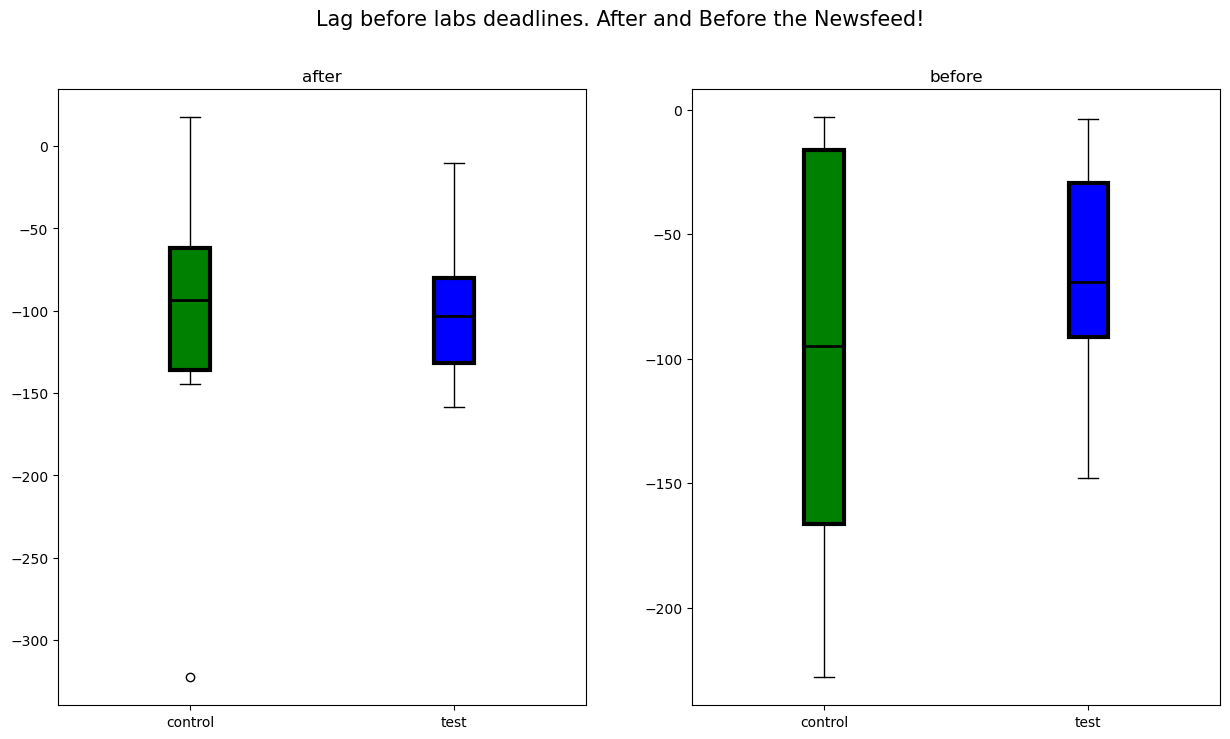

In [41]:
first_box=[
ab_test.loc[(ab_test['time'] == 'after') & (ab_test['group'] == 'control'), 'diff'],
ab_test.loc[(ab_test['time'] == 'after') & (ab_test['group'] == 'test'), 'diff']]

second_box=[
ab_test.loc[(ab_test['time'] == 'before') & (ab_test['group'] == 'control'), 'diff'],
ab_test.loc[(ab_test['time'] == 'before') & (ab_test['group'] == 'test'), 'diff']]

labels=['control', 'test']

colors=['green', 'blue']

fig, ax=plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Lag before labs deadlines. After and Before the Newsfeed!', fontsize=15)


bp1=ax[0].boxplot(first_box, patch_artist=True, tick_labels=labels)

bp2=ax[1].boxplot(second_box, patch_artist=True, tick_labels=labels)

for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

ax[0].set_title('after')
ax[1].set_title('before')

plt.show()

## Approximaitely -90